# B6 — Préparation des données images (MVTec AD, catégorie `hazelnut`)

Ce notebook prépare les images pour un auto-encodeur de détection d'anomalies (approche non supervisée : on apprend à reconstruire uniquement des pièces **saines**, et tout ce qui est mal reconstruit devient suspect).

## Étape 1 — Redimensionnement des images

Les images MVTec d'origine (`artifacts/hazelnut`) sont en haute résolution (1024×1024). On les redimensionne toutes en **256×256** et on les sauvegarde dans `artifacts/hazelnut_resized`, en conservant la structure d'origine :

- `train/good` — pièces saines pour l'entraînement,
- `test/good` — pièces saines pour l'évaluation,
- `test/<défaut>` — pièces défectueuses (crack, cut, hole, print).

On utilise l'interpolation `INTER_AREA`, adaptée à la réduction de taille, et on garde le format BGR d'OpenCV (aucune conversion de couleur nécessaire pour un simple redimensionnement disque-à-disque).

In [ ]:
import shutil
from pathlib import Path

import cv2

DATA_DIR = Path("artifacts/hazelnut")
IMG_SIZE = (256, 256)  # (largeur, hauteur)
DIM = IMG_SIZE[0]  # dimension utilisée pour nommer le dossier et les fichiers
RESIZED_DIR = Path(f"artifacts/hazelnut_resized_{DIM}")


# Log du nombre d'images par dossier (train, test) et sous-dossier
splits = [s for s in ["train", "test"] if (DATA_DIR / s).is_dir()]
counts = {
    split: {
        sub.name: len(list(sub.glob("*.png")))
        for sub in sorted(p for p in (DATA_DIR / split).iterdir() if p.is_dir())
    }
    for split in splits
}
grand_total = sum(sum(c.values()) for c in counts.values())

print(f"Contenu de {DATA_DIR} (total : {grand_total} images) :")
for split in splits:
    total_split = sum(counts[split].values())
    pct_split = total_split / grand_total if grand_total else 0
    print(f"{split} ({total_split} images, {pct_split:.1%} du total) :")
    for name, n in counts[split].items():
        print(f"  {name:<8}: {n} images")
print()


def resize_folder_to_disk(src_dir, dst_dir, size=IMG_SIZE):
    """Redimensionne les images .png de src_dir (couleur) et les écrit dans dst_dir (suffixe _{DIM})."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    paths = sorted(Path(src_dir).glob("*.png"))
    for path in paths:
        img = cv2.imread(str(path))  # BGR (format natif OpenCV, réutilisé tel quel pour imwrite)
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)  # INTER_AREA = réduction de taille
        cv2.imwrite(str(dst_dir / f"{path.stem}_{DIM}{path.suffix}"), img)
    return len(paths)


# On repart d'un dossier propre : suppression de RESIZED_DIR s'il existe
if RESIZED_DIR.exists():
    shutil.rmtree(RESIZED_DIR)
    print(f"Dossier existant supprimé : {RESIZED_DIR}")

total = 0

# Images (couleur) : train/ et test/ uniquement (ground_truth ignoré)
for split in ["train", "test"]:
    for sub in sorted(p for p in (DATA_DIR / split).iterdir() if p.is_dir()):
        n = resize_folder_to_disk(sub, RESIZED_DIR / split / sub.name)
        total += n
        print(f"{split}/{sub.name:<6}: {n} images -> {RESIZED_DIR / split / sub.name}")

print(f"\nTotal : {total} fichiers redimensionnés en {IMG_SIZE[0]}×{IMG_SIZE[1]} dans {RESIZED_DIR}")

In [ ]:
n_resized = len(list(RESIZED_DIR.rglob("*.png")))
print(f"{n_resized} images redimensionnées et sauvegardées dans {RESIZED_DIR}")

## Étape 2 — Pipeline d'augmentation (Albumentations)

On construit un pipeline d'augmentation appliqué **uniquement aux saines d'entraînement** (`train/good`), pour agrandir artificiellement le jeu d'entraînement de l'auto-encodeur :

- **flips** horizontal et vertical,
- **rotations légères** (±15°),
- **translation / échelle** (±5 %, zoom 0.9–1.1) via `Affine`,
- **variations d'éclairage** (luminosité / contraste ±20 %).

Chaque transformation est **nommée** et appliquée individuellement aux **images redimensionnées** (`hazelnut_resized_256/train/good`). Les résultats sont sauvegardés en `.png` dans `artifacts/hazelnut_augmented`, avec **un sous-dossier par image de base** contenant toutes ses transformations (ex. `000_256/000_256_hflip.png`, `000_256/000_256_affine.png`, …). La normalisation (étape 3) portera ensuite sur ces images **et** sur les images de base.

🔎 **Point de réflexion** : la noisette est un objet **centré mais non aligné en rotation** (contrairement à `bottle`), donc flips et rotations sont ici pertinents — ils reflètent des orientations réalistes de la pièce. En revanche, une augmentation géométrique **trop forte** élargirait la notion de « normal » et rendrait l'auto-encodeur plus tolérant aux défauts (il apprendrait à bien reconstruire des variations excessives). On garde donc des transformations **modérées**, et pas de déformation qui altérerait la texture (celle-là même qui trahit les défauts).

In [ ]:
import shutil

import albumentations as A

AUGMENTED_DIR = Path("artifacts/hazelnut_augmented")

# Transformations d'augmentation nommées (p=1.0 : toujours appliquées, une par fichier de sortie)
transforms = {
    "hflip": A.HorizontalFlip(p=1.0),
    "vflip": A.VerticalFlip(p=1.0),
    "affine": A.Affine(
        scale=(0.9, 1.1),                 # zoom léger
        translate_percent=(-0.05, 0.05),  # translation ±5 %
        rotate=(-15, 15),                 # rotation légère ±15°
        p=1.0,
    ),
    "brightness_contrast": A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=1.0,
    ),
}

# Pipeline combiné (transformations aléatoires enchaînées) pour la visualisation
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])


def augment_image(img):
    """Applique le pipeline d'augmentation combiné à une image (renvoie une version augmentée)."""
    return augment(image=img)["image"]


# On repart d'un dossier propre : suppression de AUGMENTED_DIR s'il existe
if AUGMENTED_DIR.exists():
    shutil.rmtree(AUGMENTED_DIR)
    print(f"Dossier existant supprimé : {AUGMENTED_DIR}")

# Génération : un sous-dossier par image de base, contenant toutes ses transformations
# (images redimensionnées de train/good, sauvegardées en .png)
src_dir = RESIZED_DIR / "train" / "good"
paths = sorted(src_dir.glob("*.png"))

total = 0
for path in paths:
    img = cv2.imread(str(path))  # BGR uint8 (réutilisé tel quel pour imwrite)
    dst_dir = AUGMENTED_DIR / path.stem  # un dossier par image de base (ex : 000_256/)
    dst_dir.mkdir(parents=True, exist_ok=True)
    for name, tf in transforms.items():
        aug = tf(image=img)["image"]
        cv2.imwrite(str(dst_dir / f"{path.stem}_{name}.png"), aug)  # ex : 000_256/000_256_hflip.png
        total += 1

print(f"{len(paths)} images de base × {len(transforms)} transformations = {total} fichiers augmentés")
print(f"un dossier par image dans {AUGMENTED_DIR} — transformations : {', '.join(transforms)}")

## Visualisation : original vs chaque transformation

On affiche l'image saine d'origine, puis **chacune des transformations nommées** appliquée individuellement (`hflip`, `vflip`, `affine`, `brightness_contrast`) — exactement celles sauvegardées dans `hazelnut_augmented`.

In [ ]:
import matplotlib.pyplot as plt

# Image de base redimensionnée (première saine de train/good)
first = sorted((RESIZED_DIR / "train" / "good").glob("*.png"))[0]
original_bgr = cv2.imread(str(first))  # BGR uint8 (transfos appliquées comme à la sauvegarde)

n = len(transforms) + 1
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

# Originale (BGR -> RGB pour l'affichage)
axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originale")
axes[0].axis("off")

# Une vignette par transformation nommée
for ax, (name, tf) in zip(axes[1:], transforms.items()):
    aug = tf(image=original_bgr)["image"]
    ax.imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Étape 3 — Normalisation des images augmentées

Une fois les images augmentées générées, on les normalise des pixels **[0, 255]** vers **[0, 1]** (division par 255). Cela stabilise l'entraînement de l'auto-encodeur et met les entrées dans le même intervalle que la sortie sigmoïde du décodeur. La normalisation porte **uniquement sur `hazelnut_augmented`**.

Comme la normalisation produit des valeurs **flottantes**, on ne peut pas les stocker en PNG (format entier) : chaque image est sauvegardée en **`.npy`** (tableau NumPy `float32` en RGB) dans `artifacts/hazelnut_normalised`, en conservant l'arborescence (un sous-dossier par image de base) et avec le suffixe `_norm`.

In [ ]:
import shutil

import numpy as np

NORMALISED_DIR = Path("artifacts/hazelnut_normalised")


def normalise_tree_to_disk(src_root, dst_root):
    """Normalise toutes les .png sous src_root en .npy (RGB float32 [0, 1]) sous dst_root,
    en conservant l'arborescence relative et en ajoutant le suffixe _norm au nom."""
    src_root, dst_root = Path(src_root), Path(dst_root)
    paths = sorted(src_root.rglob("*.png"))
    for path in paths:
        img = cv2.imread(str(path))                    # BGR uint8
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # -> RGB
        img = img.astype("float32") / 255.0            # [0, 255] -> [0, 1]
        dst_dir = dst_root / path.relative_to(src_root).parent
        dst_dir.mkdir(parents=True, exist_ok=True)
        np.save(dst_dir / f"{path.stem}_norm.npy", img)
    return len(paths)


# On repart d'un dossier propre : suppression de NORMALISED_DIR s'il existe
if NORMALISED_DIR.exists():
    shutil.rmtree(NORMALISED_DIR)
    print(f"Dossier existant supprimé : {NORMALISED_DIR}")

# Normalisation des images augmentées uniquement (hazelnut_augmented)
n_aug = normalise_tree_to_disk(AUGMENTED_DIR, NORMALISED_DIR)

print(f"Total : {n_aug} images augmentées normalisées (float32) dans {NORMALISED_DIR}")

## Étape 4 — Split train / validation / test

L'auto-encodeur s'*entraîne* sur des **saines** uniquement, mais **détecter** une anomalie suppose de fixer un seuil et de le vérifier sur des **saines ET des défectueuses**. D'où trois jeux (toutes les images normalisées `[0, 1]`) :

- **`X_train`** — images **augmentées saines** (`hazelnut_augmented`), mélangées. Sert à *entraîner* la reconstruction.
- **`X_val`** — mélange **saines + défectueuses** (moitié de `test/good` + moitié des `test/<défaut>`), avec étiquettes `y_val` (0 = saine, 1 = anomalie). Sert à *calibrer le seuil* de détection et à surveiller les métriques.
- **`X_test`** — l'autre moitié, même composition (`y_test`). Sert à l'*évaluation finale* non biaisée.

> **Early stopping** : basé sur la *reconstruction*, il ne doit être jugé que sur des **saines**. On isole donc `X_val_good` (la partie saine de la validation) comme `validation_data` de l'auto-encodeur. Les défauts ne servent qu'au **seuil** et à l'**évaluation** — jamais à l'apprentissage de reconstruction.

In [39]:
import numpy as np


def load_png_tree(root):
    """Charge récursivement les .png sous root, normalise en [0, 1] (RGB float32),
    en un tableau (N, 256, 256, 3)."""
    paths = sorted(Path(root).rglob("*.png"))
    imgs = [cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB).astype("float32") / 255.0 for p in paths]
    return np.stack(imgs)


rng = np.random.default_rng(42)


def shuffle(arr):
    """Mélange reproductible des lignes d'un tableau."""
    return arr[rng.permutation(len(arr))]


# --- TRAIN : images augmentées saines (reconstruction) ---
X_train = shuffle(load_png_tree(AUGMENTED_DIR))

# --- VALIDATION + TEST : saines (test/good) ET défectueuses (test/<défaut>) ---
test_dir = RESIZED_DIR / "test"
good = load_png_tree(test_dir / "good")                       # normales -> label 0
defects = np.concatenate([                                    # anomalies -> label 1
    load_png_tree(sub)
    for sub in sorted(test_dir.iterdir())
    if sub.is_dir() and sub.name != "good"
])

# On mélange chaque classe puis on la coupe en deux : 50 % validation / 50 % test
good, defects = shuffle(good), shuffle(defects)
g_mid, d_mid = len(good) // 2, len(defects) // 2
good_val, good_test = good[:g_mid], good[g_mid:]
def_val, def_test = defects[:d_mid], defects[d_mid:]

# Jeux mixtes (saines + défectueuses) avec étiquettes : 0 = saine, 1 = anomalie
X_val = np.concatenate([good_val, def_val])
y_val = np.concatenate([np.zeros(len(good_val)), np.ones(len(def_val))]).astype(int)
X_test = np.concatenate([good_test, def_test])
y_test = np.concatenate([np.zeros(len(good_test)), np.ones(len(def_test))]).astype(int)

# Sous-ensemble SAIN de la validation : sert à l'early stopping (reconstruction sur des saines)
X_val_good = good_val

print(f"X_train    : {X_train.shape} (augmentées saines)")
print(f"X_val      : {X_val.shape} -> {int((y_val == 0).sum())} saines + {int((y_val == 1).sum())} défauts")
print(f"X_test     : {X_test.shape} -> {int((y_test == 0).sum())} saines + {int((y_test == 1).sum())} défauts")
print(f"X_val_good : {X_val_good.shape} (early stopping)")

X_train    : (1564, 256, 256, 3) (augmentées saines)
X_val      : (55, 256, 256, 3) -> 20 saines + 35 défauts
X_test     : (55, 256, 256, 3) -> 20 saines + 35 défauts
X_val_good : (20, 256, 256, 3) (early stopping)


## Vérification visuelle : toutes les transformations, saine vs défectueuse

On affiche l'originale puis **chaque transformation nommée** (`hflip`, `vflip`, `affine`, `brightness_contrast`), sur une ligne pour une pièce **saine** (`train/good`) et une ligne pour une pièce **défectueuse** (`test/crack`) — pour vérifier le rendu des augmentations et comparer visuellement une pièce normale et une pièce avec fissure.

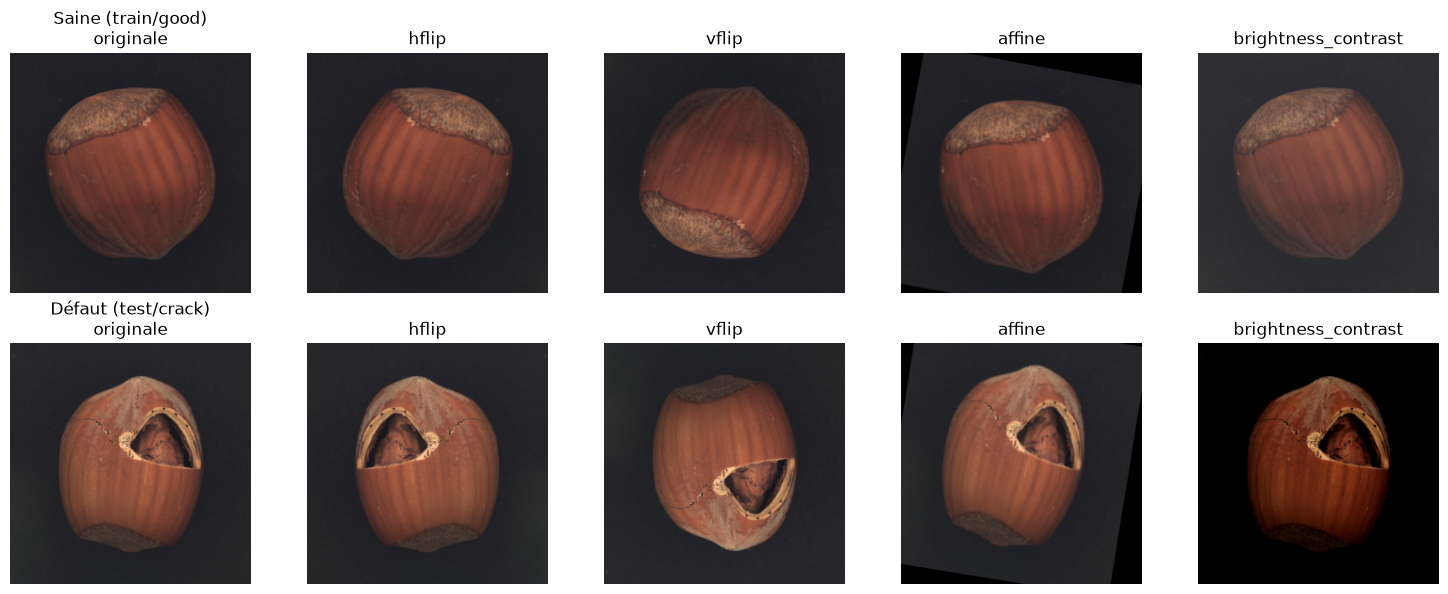

In [32]:
import matplotlib.pyplot as plt

# Une image saine et une défectueuse (redimensionnées)
samples = {
    "Saine (train/good)": sorted((RESIZED_DIR / "train" / "good").glob("*.png"))[0],
    "Défaut (test/crack)": sorted((RESIZED_DIR / "test" / "crack").glob("*.png"))[0],
}

n_cols = len(transforms) + 1
fig, axes = plt.subplots(len(samples), n_cols, figsize=(3 * n_cols, 3 * len(samples)))

for row, (label, path) in enumerate(samples.items()):
    img_bgr = cv2.imread(str(path))  # BGR uint8 (transfos appliquées comme à la sauvegarde)

    # Originale (BGR -> RGB pour l'affichage)
    axes[row][0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[row][0].set_title(f"{label}\noriginale")
    axes[row][0].axis("off")

    # Une vignette par transformation nommée
    for col, (name, tf) in enumerate(transforms.items(), start=1):
        aug = tf(image=img_bgr)["image"]
        axes[row][col].imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
        axes[row][col].set_title(name)
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()

## Partie 2 — Auto-encodeur convolutif

On entraîne un auto-encodeur **convolutif** à reconstruire les images saines **augmentées** (`X_train`). L'architecture est symétrique, avec **3 couches de convolution** puis **3 couches de déconvolution** :

- **Encodeur** — 3 `Conv2D` (stride 2) qui réduisent la résolution `256 → 128 → 64 → 32` en augmentant la profondeur `32 → 64 → 128` (le « goulot » / représentation latente).
- **Décodeur** — 3 `Conv2DTranspose` (stride 2) qui remontent `32 → 64 → 128 → 256`, la dernière produisant 3 canaux avec activation **sigmoïde** (sortie dans `[0, 1]`, comme les entrées normalisées).

La perte est la **MSE** (erreur de reconstruction pixel à pixel) : une pièce mal reconstruite (erreur élevée) sera considérée comme anormale dans la suite. L'entrée du réseau est de taille **`(256, 256, 3)`**, imposée par nos images prétraitées.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

IMG_SHAPE = (256, 256, 3)  # (hauteur, largeur, canaux) — cf. X_train

# --- Auto-encodeur convolutif : 3 convolutions (encodeur) + 3 déconvolutions (décodeur) ---
inp = keras.Input(shape=IMG_SHAPE)

# Encodeur : 3 couches de convolution (stride 2 -> réduction spatiale, profondeur croissante)
x = layers.Conv2D(32, 3, strides=2, activation="relu", padding="same")(inp)       # 256 -> 128
x = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)         # 128 -> 64
encoded = layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)  # 64  -> 32 (goulot / latent)

# Décodeur : 3 couches de déconvolution (stride 2 -> reconstruction spatiale)
x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(encoded)     # 32  -> 64
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)           # 64  -> 128
decoded = layers.Conv2DTranspose(3, 3, strides=2, activation="sigmoid", padding="same")(x)   # 128 -> 256, sortie [0, 1]

autoencoder = keras.Model(inp, decoded, name="conv_autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")  # MSE = erreur de reconstruction pixel à pixel
autoencoder.summary()

# Early stopping : arrête quand la val_loss ne s'améliore plus de façon significative.
# min_delta : une baisse plus petite que ce seuil n'est PAS comptée comme une amélioration
# (sinon les micro-gains à chaque époque empêchent l'arrêt et on va jusqu'à epochs=50).
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1,
)

# Entraînement sur les saines augmentées (entrée = cible : on apprend à se reconstruire).
# Validation sur des saines uniquement (X_val_good) : la reconstruction ne doit être jugée
# que sur du normal, jamais sur des défauts.
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    shuffle=True,
    validation_data=(X_val_good, X_val_good),
    callbacks=[early_stopping],
)

## Courbes d'apprentissage + suivi MLflow

On trace l'évolution de la perte de reconstruction (MSE) au fil des époques — entraînement (`loss`) et validation saine (`val_loss`) — la ligne verticale marquant la **meilleure époque** retenue par l'early stopping (poids restaurés).

Lecture : les deux courbes doivent **descendre puis se stabiliser**. Si `val_loss` remonte alors que `loss` continue de baisser, c'est du **sur-apprentissage** — et c'est justement là que l'early stopping intervient.

Dans le **même bloc**, on enregistre le run dans **MLflow** (backend SQLite `mlflow.db`) : les hyperparamètres, les pertes par époque, le **graphe d'apprentissage** en artefact (`learning_curve.png`) et le **modèle** entraîné. Consulter les runs avec `mlflow ui --backend-store-uri sqlite:///mlflow.db`.

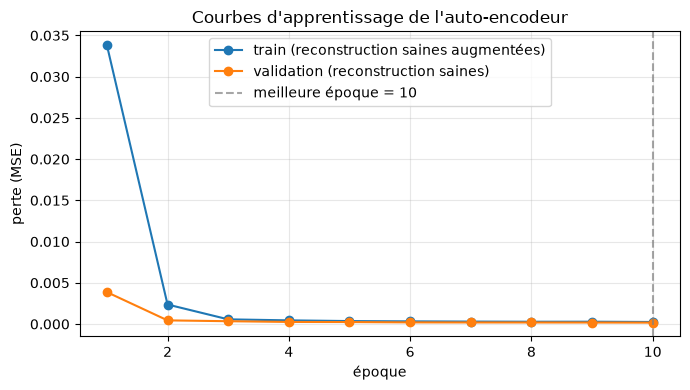

2026/07/21 15:43:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 15:43:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/avallet/formation-ia-project
2026/07/21 15:43:52 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/07/21 15:43:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/avallet/formation-ia-project
2026/07/21 15:43:52 INFO mlflow.utils.environment: Detected uv project at /Users/avallet/formation-ia-project. Attempting to export requirements via 'uv export'.
2026/07/21 15:43:53 INFO mlflow.utils.uv_utils: Exported 192 dependencies via uv
2026/07/21 15:43:53 INFO mlflow.utils.environment: Successfully exported 192 requirements from uv proje

Run loggé dans MLflow (expérience « hazelnut_anomaly_autoencoder », run_id=a7a22341f07a44de82a4aed1bc7342f4).
UI : mlflow ui --backend-store-uri sqlite:///mlflow.db


In [49]:
import matplotlib.pyplot as plt
import mlflow
import mlflow.tensorflow

MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
MLFLOW_EXPERIMENT_NAME = "hazelnut_anomaly_autoencoder"

# --- Courbe d'apprentissage train / validation ---
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
best_epoch = int(np.argmin(val_loss)) + 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, loss, marker="o", label="train (reconstruction saines augmentées)")
ax.plot(epochs, val_loss, marker="o", label="validation (reconstruction saines)")
ax.axvline(best_epoch, color="grey", linestyle="--", alpha=0.7, label=f"meilleure époque = {best_epoch}")
ax.set_xlabel("époque")
ax.set_ylabel("perte (MSE)")
ax.set_title("Courbes d'apprentissage de l'auto-encodeur")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# --- Log du run dans MLflow : hyperparamètres, métriques, courbe et modèle ---
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

with mlflow.start_run(run_name="conv_autoencoder") as run:
    # Hyperparamètres
    mlflow.log_params({
        "img_shape": IMG_SHAPE,
        "epochs_max": 50,
        "batch_size": 16,
        "optimizer": "adam",
        "loss": "mse",
        "early_stopping_patience": 5,
        "n_train": len(X_train),
        "n_val_good": len(X_val_good),
    })

    # Perte par époque (courbes natives MLflow) + résumé
    for step, (tr, va) in enumerate(zip(loss, val_loss), start=1):
        mlflow.log_metric("loss", tr, step=step)
        mlflow.log_metric("val_loss", va, step=step)
    mlflow.log_metric("epochs_ran", len(loss))
    mlflow.log_metric("best_epoch", best_epoch)
    mlflow.log_metric("train_loss_final", loss[-1])
    mlflow.log_metric("val_loss_best", min(val_loss))

    # Graphe d'apprentissage (artefact) + modèle entraîné
    mlflow.log_figure(fig, "learning_curve.png")
    mlflow.tensorflow.log_model(autoencoder, "model")

# On mémorise l'ID du run pour y rattacher l'exemple de reconstruction (cellule suivante)
RUN_ID = run.info.run_id

print(f"Run loggé dans MLflow (expérience « {MLFLOW_EXPERIMENT_NAME} », run_id={RUN_ID}).")
print(f"UI : mlflow ui --backend-store-uri {MLFLOW_TRACKING_URI}")

## Exemple de reconstruction (jeu de test) — MSE & SSIM

Pour une image **saine** et une image **défectueuse** de `X_test`, on affiche l'**originale**, sa **reconstruction**, puis deux comparaisons :

- **MSE** — erreur pixel à pixel : *plus c'est haut, plus c'est anormal*.
- **SSIM** (*Structural Similarity*) dans `[-1, 1]` : mesure la similarité **structurelle** (luminance, contraste, structure locale) plutôt que la seule différence de pixels — *plus c'est proche de 1, plus la reconstruction est fidèle*. On affiche la carte de **dissimilarité** `1 − SSIM` (haut = anormal).

Attendu : sur une saine, MSE faible et SSIM ≈ 1. Sur un défaut, la zone anormale (jamais apprise) est **mal reconstruite** → l'erreur MSE **et** la dissimilarité SSIM s'y **concentrent**, et le SSIM global chute. SSIM est souvent plus discriminant que la MSE car il réagit aux **altérations de structure/texture** (typiques des défauts) plutôt qu'à de simples écarts d'intensité.

Cette figure est enregistrée comme artefact (`reconstruction_examples.png`) dans le **même run MLflow** que la courbe d'apprentissage (via `RUN_ID` mémorisé à la cellule précédente).

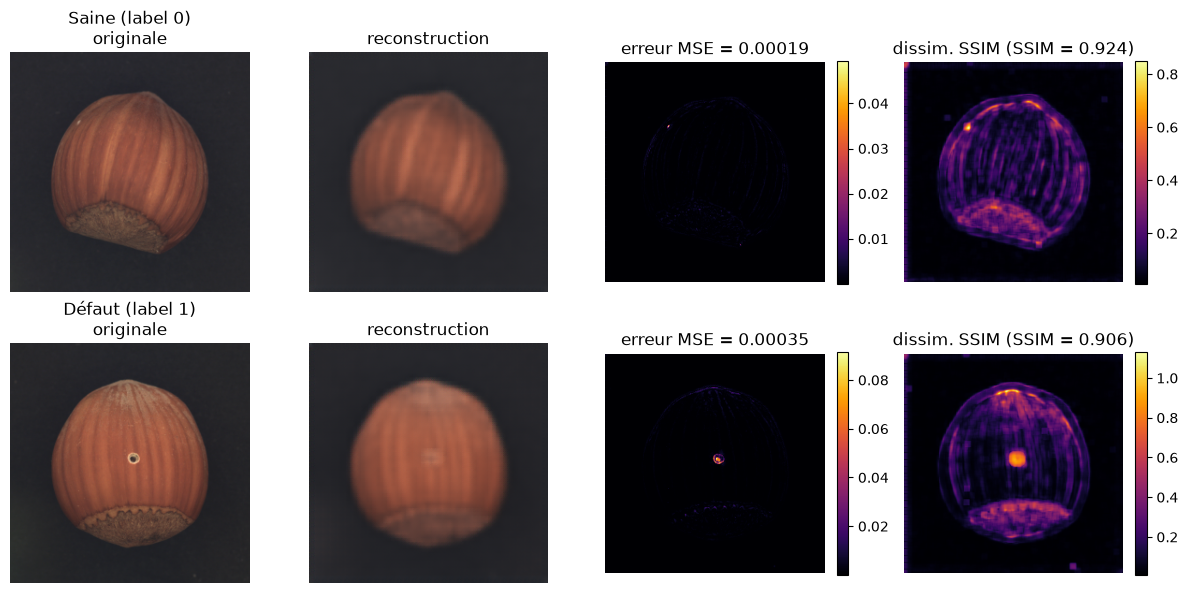

Exemple de reconstruction ajouté au run MLflow a7a22341f07a44de82a4aed1bc7342f4.


In [50]:
import matplotlib.pyplot as plt
import mlflow
from skimage.metrics import structural_similarity

# Un exemple sain et un exemple défectueux du jeu de test
idx_good = int(np.where(y_test == 0)[0][0])
idx_defect = int(np.where(y_test == 1)[0][0])
examples = [("Saine (label 0)", idx_good), ("Défaut (label 1)", idx_defect)]

fig, axes = plt.subplots(len(examples), 4, figsize=(12, 3 * len(examples)))

for row, (label, idx) in enumerate(examples):
    original = X_test[idx]
    recon = autoencoder.predict(original[None, ...], verbose=0)[0]   # reconstruction (256, 256, 3)

    # MSE : erreur pixel à pixel (plus c'est haut, plus c'est anormal)
    error_map = np.mean((original - recon) ** 2, axis=-1)            # MSE par pixel
    mse = float(error_map.mean())                                    # MSE de l'image

    # SSIM : similarité structurelle dans [-1, 1] (1 = identique). On récupère aussi la carte locale.
    ssim, ssim_map = structural_similarity(
        original, recon, channel_axis=-1, data_range=1.0, full=True
    )
    dissim_map = 1.0 - ssim_map.mean(axis=-1)                        # dissimilarité (haut = anormal)

    axes[row][0].imshow(original)
    axes[row][0].set_title(f"{label}\noriginale")
    axes[row][1].imshow(recon)
    axes[row][1].set_title("reconstruction")
    im_mse = axes[row][2].imshow(error_map, cmap="inferno")
    axes[row][2].set_title(f"erreur MSE = {mse:.5f}")
    im_ssim = axes[row][3].imshow(dissim_map, cmap="inferno")
    axes[row][3].set_title(f"dissim. SSIM (SSIM = {ssim:.3f})")
    for ax in axes[row]:
        ax.axis("off")
    fig.colorbar(im_mse, ax=axes[row][2], fraction=0.046)
    fig.colorbar(im_ssim, ax=axes[row][3], fraction=0.046)

plt.tight_layout()
plt.show()

# Log de l'exemple de reconstruction dans le MÊME run MLflow que la courbe d'apprentissage
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_figure(fig, "reconstruction_examples.png")

print(f"Exemple de reconstruction ajouté au run MLflow {RUN_ID}.")